<a href="https://colab.research.google.com/github/Sakshii248/world-happiness-analysis/blob/main/world_happiness_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd

url = "https://raw.githubusercontent.com/Sakshii248/world-happiness-analysis/main/data/pone.0322287.s001.xlsx"
df = pd.read_excel(url)

# To inspect the sheets of the Excel file, you should pass the URL
# (or file path if it were a local file) to pd.ExcelFile, not the DataFrame.
xls = pd.ExcelFile(url)

# Check sheet names
print(xls.sheet_names)

['2020', '2021', '2022', '2023', '2024']


In [16]:
import pandas as pd

url = "https://raw.githubusercontent.com/Sakshii248/world-happiness-analysis/main/data/pone.0322287.s001.xlsx"

# Load all sheets into a dictionary
all_sheets = pd.read_excel(url, sheet_name=None)

# Check sheet names
print(all_sheets.keys())


dict_keys(['2020', '2021', '2022', '2023', '2024'])


In [17]:
import pandas as pd

url = "https://raw.githubusercontent.com/Sakshii248/world-happiness-analysis/main/data/pone.0322287.s001.xlsx"

# Load all sheets into a dictionary
all_sheets = pd.read_excel(url, sheet_name=None)
# View first few rows of 2020 data(only one statement works at once)
all_sheets['2020'].head()
all_sheets['2021'].head() #show head of 2021
all_sheets['2020'].info() #get the info of 2020

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  156 non-null    int64  
 1   Country or region             156 non-null    object 
 2   Score                         156 non-null    float64
 3   GDP per capita                156 non-null    float64
 4   Social support                156 non-null    float64
 5   Healthy life expectancy       156 non-null    float64
 6   Freedom to make life choices  156 non-null    float64
 7   Generosity                    156 non-null    float64
 8   Perceptions of corruption     156 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 11.1+ KB


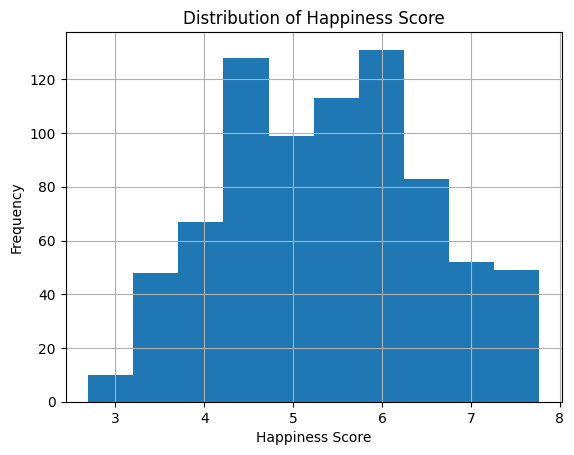

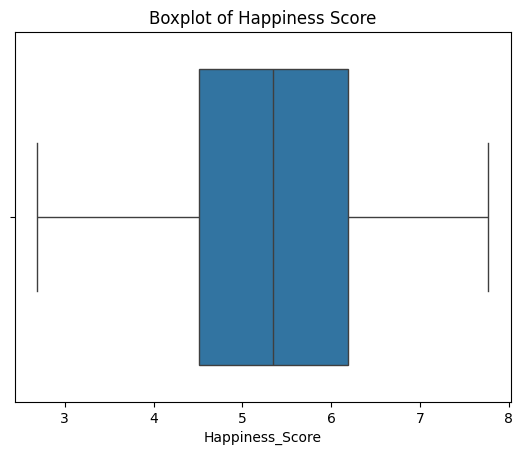

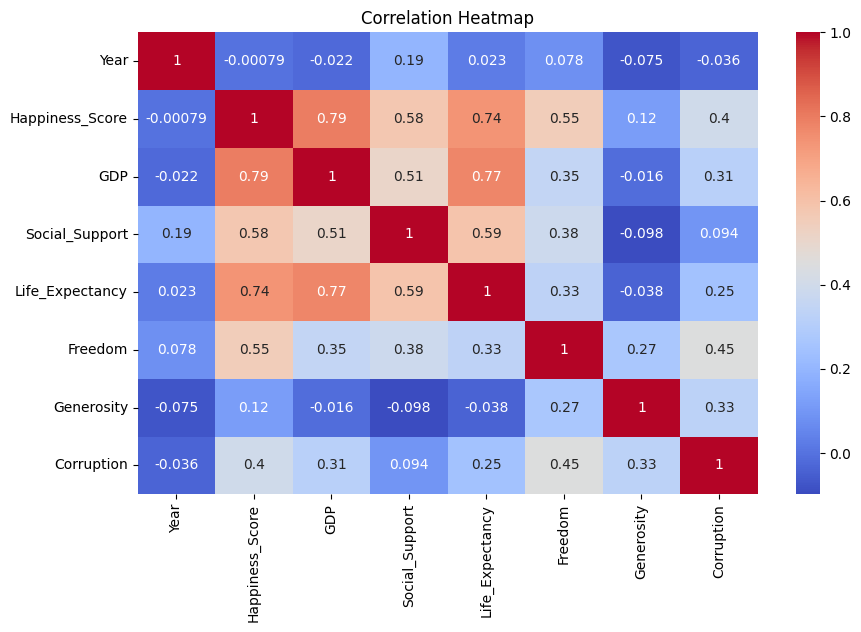

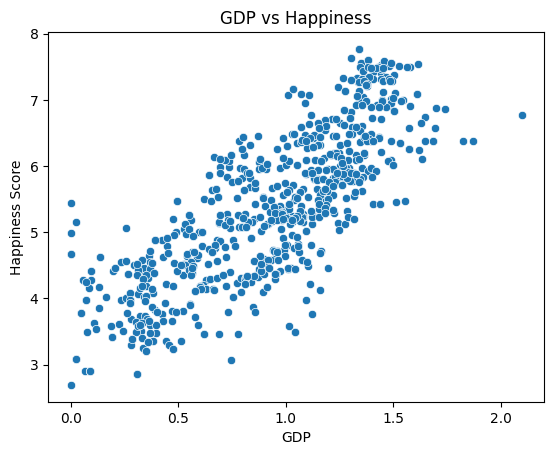

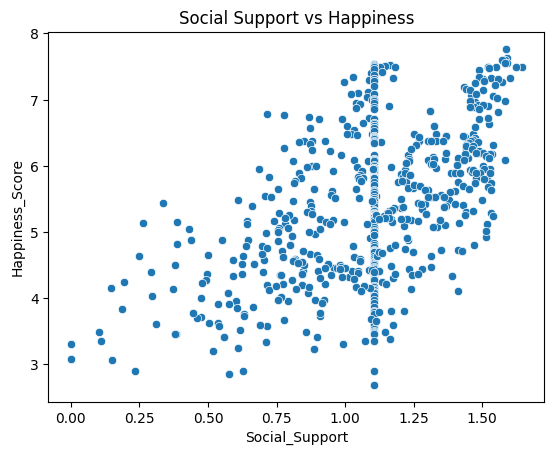

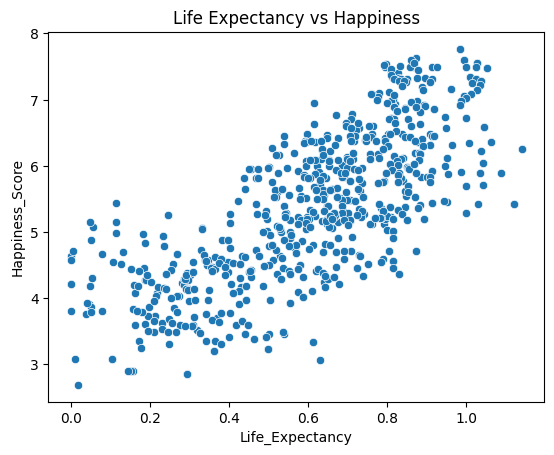

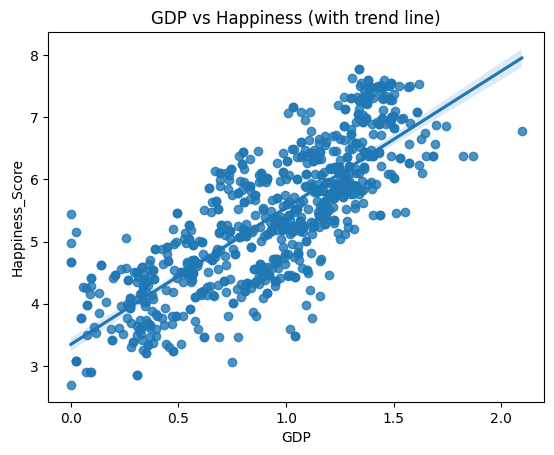

In [62]:
import pandas as pd

url = "https://raw.githubusercontent.com/Sakshii248/world-happiness-analysis/main/data/pone.0322287.s001.xlsx"

# Load all sheets into a dictionary
all_sheets = pd.read_excel(url, sheet_name=None)
def clean_modern(df, year):
    df = df.copy()

    df = df.rename(columns={
        'Country or region': 'Country',
        'Score': 'Happiness_Score',
        'GDP per capita': 'GDP',
        'Social support': 'Social_Support',
        'Healthy life expectancy': 'Life_Expectancy',
        'Freedom to make life choices': 'Freedom',
        'Perceptions of corruption': 'Corruption'
    })

    df['Year'] = year

    # Ensure structure consistency
    df = df.reindex(columns=[
        'Country', 'Year', 'Happiness_Score', 'GDP',
        'Social_Support', 'Life_Expectancy',
        'Freedom', 'Generosity', 'Corruption'
    ])

    return df
df_all = pd.concat([df_2020, df_2021, df_2022, df_2023, df_2024], ignore_index=True)

df_all.head()
df_all.shape #shows row and column numbers
df_all.sample(5) #shows random n data values
df_all.columns #shows column names
df_all.isnull().sum() #shows null values
df_cleaned = df_all.copy()

# Fill numerical columns with mean
numeric_cols = df_cleaned.select_dtypes(include=['float64', 'int64']).columns

for col in numeric_cols:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mean())
df_cleaned.isnull().sum()
df_all.duplicated().sum() #shows duplicate values
df_cleaned = df_cleaned.drop_duplicates() #drop duplicate values
#df_cleaned.info()
df_cleaned.describe() #describe cleaned data

#Distribution (Histogram)
import matplotlib.pyplot as plt

df_cleaned['Happiness_Score'].hist()
plt.title('Distribution of Happiness Score')
plt.xlabel('Happiness Score')
plt.ylabel('Frequency')
plt.show()

#Boxplot (Detect Outliers)
import seaborn as sns

sns.boxplot(x=df_cleaned['Happiness_Score'])
plt.title('Boxplot of Happiness Score')
plt.show()

#Correlation Heatmap
plt.figure(figsize=(10,6))

corr = df_cleaned.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

corr['Happiness_Score'].sort_values(ascending=False) #checks corelation with happiness

#Feature Relationships GDP vs happiness

sns.scatterplot(x='GDP', y='Happiness_Score', data=df_cleaned)

plt.title('GDP vs Happiness')
plt.xlabel('GDP')
plt.ylabel('Happiness Score')

plt.show()

#social support vs happiness
sns.scatterplot(x='Social_Support', y='Happiness_Score', data=df_cleaned)

plt.title('Social Support vs Happiness')
plt.show()

#life expectancy vs happiness
sns.scatterplot(x='Life_Expectancy', y='Happiness_Score', data=df_cleaned)

plt.title('Life Expectancy vs Happiness')
plt.show()

#add regression line
sns.regplot(x='GDP', y='Happiness_Score', data=df_cleaned)
plt.title('GDP vs Happiness (with trend line)')
plt.show()